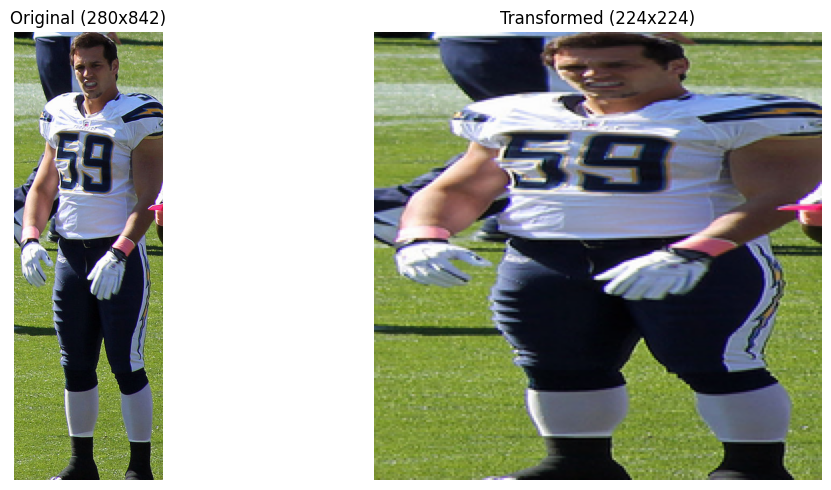

Square images: 526
Non-square images: 29474


In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Load images from subdirectories
data_dir = '../Deep-Learning-for-fake-detection-and-generation/datasets/extracted/wiki/wiki/'
image_files = []

for subdir in os.listdir(data_dir):
    subdir_path = os.path.join(data_dir, subdir)
    if os.path.isdir(subdir_path):
        for f in os.listdir(subdir_path):
            if f.lower().endswith(('.jpg', '.png')):
                image_files.append(os.path.join(subdir_path, f))

if not image_files:
    print("No image files found in the directory!")
else:
    # Find the image with the most extreme aspect ratio
    least_square_idx = 0
    max_aspect_ratio = 0
    
    for idx, filepath in enumerate(image_files):
        img = Image.open(filepath)
        width, height = img.size
        aspect_ratio = max(width, height) / min(width, height)
        
        if aspect_ratio > max_aspect_ratio:
            max_aspect_ratio = aspect_ratio
            least_square_idx = idx
    
    # Get the image with the most extreme aspect ratio
    original_img = Image.open(image_files[least_square_idx])
    
    # Transform to 224x224
    transformed_img = original_img.resize((224, 224), Image.Resampling.LANCZOS)
    
    # Display side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].imshow(original_img)
    axes[0].set_title(f'Original ({original_img.width}x{original_img.height})')
    axes[0].axis('off')
    
    axes[1].imshow(transformed_img)
    axes[1].set_title('Transformed (224x224)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

    # Count square and non-square images
    square_count = 0
    non_square_count = 0

    for filepath in image_files:
        img = Image.open(filepath)
        width, height = img.size
        if width == height:
            square_count += 1
        else:
            non_square_count += 1

    print(f"Square images: {square_count}")
    print(f"Non-square images: {non_square_count}")